In [1]:
# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


# Projeto 21: Previsão do preço de ações com redes neurais recorrentes - múltiplos previsores

## Etapa 1: Importação das bibliotecas

Coluna open e outras colunas para serem trabalhadas no forecast múltiplos

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from sklearn.metrics import mean_absolute_error
torch.__version__

'2.9.1+cpu'

In [3]:
torch.manual_seed(123) # semente, gerar sempre o mesmo valor

## Etapa 2: Base de dados

In [4]:
base = pd.read_csv('petr4_treinamento.csv')

In [5]:
base.tail(2)

,Date,Open,High,Low,Close,Adj Close,Volume
1243,2017-12-28,16.1,16.129999,16.0,16.1,16.067865,19011500.0
1244,2017-12-29,16.1,16.100000,16.1,16.1,16.067865,0.0


In [6]:
base.isnull().sum()

Date         0
Open         3
High         3
Low          3
Close        3
Adj Close    3
Volume       3
dtype: int64

In [7]:
# retirar as linhas nulas
base = base.dropna()


In [8]:
base.columns[1:7] # colunas a serem trabalhados, tirando a coluna Date

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [9]:
len(base.columns[1:7]) # coluna 1 até 7

6

In [10]:
base_treinamento = base.iloc[:, 1:7].values

In [11]:
base_treinamento

array([[1.9990000e+01, 2.0209999e+01, 1.9690001e+01, 1.9690001e+01,
        1.8086271e+01, 3.0182600e+07],
       [1.9809999e+01, 2.0400000e+01, 1.9700001e+01, 2.0400000e+01,
        1.8738441e+01, 3.0552600e+07],
       [2.0330000e+01, 2.0620001e+01, 2.0170000e+01, 2.0430000e+01,
        1.8766001e+01, 3.6141000e+07],
       ...,
       [1.5990000e+01, 1.6139999e+01, 1.5980000e+01, 1.6049999e+01,
        1.6017963e+01, 2.3552200e+07],
       [1.6100000e+01, 1.6129999e+01, 1.6000000e+01, 1.6100000e+01,
        1.6067865e+01, 1.9011500e+07],
       [1.6100000e+01, 1.6100000e+01, 1.6100000e+01, 1.6100000e+01,
        1.6067865e+01, 0.0000000e+00]])

In [12]:
base.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,19.990000,20.209999,19.690001,19.690001,18.086271,30182600.0
1,2013-01-03,19.809999,20.400000,19.700001,20.400000,18.738441,30552600.0
2,2013-01-04,20.330000,20.620001,20.170000,20.430000,18.766001,36141000.0
3,2013-01-07,20.480000,20.670000,19.950001,20.080000,18.444506,28069600.0
4,2013-01-08,20.110001,20.230000,19.459999,19.500000,17.911745,29091300.0


In [13]:
# Cria o objeto de normalização: MinMaxScaler(feature_range = (0, 1))
# O MinMaxScaler é uma ferramenta que coloca todos os dados em uma escala comum.
# O 'feature_range=(0, 1)' define que o menor valor do conjunto será transformado em 0,
# e o maior valor será transformado em 1. Todos os outros ficarão entre esses dois.
normalizador = MinMaxScaler(feature_range = (0, 1))

# Aplica a normalização: fit_transform(base_treinamento)
# Esta linha faz duas tarefas importantes de uma vez:
# 1. 'fit': O computador "estuda" a base de treinamento para descobrir qual é o 
#    valor mínimo (ex: R$ 10,00) e o valor máximo (ex: R$ 500,00).
# 2. 'transform': Ele aplica a fórmula matemática em todos os dados para convertê-los
#    para a escala 0 a 1. O resultado é salvo em 'base_treinamento_normalizada'.
base_treinamento_normalizada = normalizador.fit_transform(base_treinamento)

In [14]:
base_treinamento_normalizada # base normalizado numpy

array([[0.76501938, 0.77266112, 0.79682707, 0.76080559, 0.6838135 ,
        0.04318274],
       [0.7562984 , 0.78187106, 0.79733884, 0.79567784, 0.71590949,
        0.0437121 ],
       [0.78149225, 0.79253519, 0.82139202, 0.79715132, 0.71726583,
        0.05170752],
       ...,
       [0.57122093, 0.57537562, 0.60696008, 0.58202356, 0.58202349,
        0.03369652],
       [0.57655039, 0.57489089, 0.60798362, 0.5844794 , 0.58447937,
        0.02720006],
       [0.57655039, 0.57343674, 0.61310133, 0.5844794 , 0.58447937,
        0.        ]])

In [15]:
base_treinamento_normalizada[0:6]

array([[0.76501938, 0.77266112, 0.79682707, 0.76080559, 0.6838135 ,
        0.04318274],
       [0.7562984 , 0.78187106, 0.79733884, 0.79567784, 0.71590949,
        0.0437121 ],
       [0.78149225, 0.79253519, 0.82139202, 0.79715132, 0.71726583,
        0.05170752],
       [0.78875969, 0.7949588 , 0.81013311, 0.77996075, 0.70144373,
        0.04015963],
       [0.77083338, 0.77363063, 0.78505624, 0.75147351, 0.67522435,
        0.0416214 ],
       [0.74806197, 0.75618037, 0.78505624, 0.76031438, 0.68336137,
        0.03485382]])

In [16]:
len(base_treinamento_normalizada) # quantidade geral das linhas

1242

In [17]:
base2 = base.drop(columns='Date')

In [18]:
base2.columns[0:6]
    

Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')

In [19]:
base2.columns[0]

'Open'

In [20]:
# estrutura de dados, com dados de 0:6 das colunas
# estrutura mais complexa
# Inicializa listas vazias para armazenar as janelas de tempo (X) e os alvos (y)
X = []
y = []

# O loop percorre os dados da linha 90 até a 1241 (o final do seu treino)
# 90 é o "tamanho da memória": a rede sempre olhará 90 dias para trás.
for i in range(90, 1242):
    # Pega os 90 dias anteriores (de i-90 até i) e outras colunas bases para a previsão
    # X.append: Pega as 6 colunas (0:6) dos 90 dias anteriores (de i-90 até i)
    # Isso cria a "janela de observação" que a LSTM usará para aprender o padrão.
    X.append(base_treinamento_normalizada[i-90:i, 0:6])
    
    # y.append: Pega apenas a 1ª coluna (0) da linha ATUAL (i)
    # Este é o "alvo": o valor que a rede deve tentar adivinhar com base nos 90 dias anteriores.
    y.append(base_treinamento_normalizada[i, 0]) # previsão

# Transforma as listas de Python em Arrays do NumPy (Matrizes matemáticas)
# O PyTorch e o Scikit-Learn precisam desse formato para processar os cálculos.
X, y = np.array(X), np.array(y)


In [21]:
X[0] # trazendo todos os atributos para a previsão
# 90 datas anteriores de cada coluna base

array([[0.76501938, 0.77266112, 0.79682707, 0.76080559, 0.6838135 ,
        0.04318274],
       [0.7562984 , 0.78187106, 0.79733884, 0.79567784, 0.71590949,
        0.0437121 ],
       [0.78149225, 0.79253519, 0.82139202, 0.79715132, 0.71726583,
        0.05170752],
       [0.78875969, 0.7949588 , 0.81013311, 0.77996075, 0.70144373,
        0.04015963],
       [0.77083338, 0.77363063, 0.78505624, 0.75147351, 0.67522435,
        0.0416214 ],
       [0.74806197, 0.75618037, 0.78505624, 0.76031438, 0.68336137,
        0.03485382],
       [0.75436047, 0.76490543, 0.78915051, 0.76768177, 0.69014234,
        0.02507502],
       [0.75823643, 0.76442079, 0.79733884, 0.77013751, 0.6924025 ,
        0.0260728 ],
       [0.76598837, 0.77411537, 0.79682707, 0.76227897, 0.68516964,
        0.0404927 ],
       [0.76598837, 0.77411537, 0.79682707, 0.76719061, 0.68969016,
        0.0423977 ],
       [0.76017437, 0.75714973, 0.79222108, 0.76817293, 0.69059437,
        0.02401858],
       [0.75872098, 0

In [22]:
y[0]

0.7611434108527131

In [23]:
# estrutura mais complexa resumindo no geral

In [24]:
X[1][:20] # 20 linhas

array([[0.7562984 , 0.78187106, 0.79733884, 0.79567784, 0.71590949,
        0.0437121 ],
       [0.78149225, 0.79253519, 0.82139202, 0.79715132, 0.71726583,
        0.05170752],
       [0.78875969, 0.7949588 , 0.81013311, 0.77996075, 0.70144373,
        0.04015963],
       [0.77083338, 0.77363063, 0.78505624, 0.75147351, 0.67522435,
        0.0416214 ],
       [0.74806197, 0.75618037, 0.78505624, 0.76031438, 0.68336137,
        0.03485382],
       [0.75436047, 0.76490543, 0.78915051, 0.76768177, 0.69014234,
        0.02507502],
       [0.75823643, 0.76442079, 0.79733884, 0.77013751, 0.6924025 ,
        0.0260728 ],
       [0.76598837, 0.77411537, 0.79682707, 0.76227897, 0.68516964,
        0.0404927 ],
       [0.76598837, 0.77411537, 0.79682707, 0.76719061, 0.68969016,
        0.0423977 ],
       [0.76017437, 0.75714973, 0.79222108, 0.76817293, 0.69059437,
        0.02401858],
       [0.75872098, 0.75908871, 0.79222108, 0.76178781, 0.68471746,
        0.02821315],
       [0.75581391, 0

In [25]:
y[1]

0.7611434108527131

In [26]:
# colocar em pytorch
X = torch.tensor(X, dtype = torch.float32)
y = torch.tensor(y, dtype = torch.float32)

In [27]:
# Cria o Dataset: torch.utils.data.TensorDataset(X, y)
# O TensorDataset funciona como um "grampeador". Ele une o seu tensor de entradas (X)
# ao seu tensor de respostas (y). Isso garante que cada janela de 90 dias esteja
# perfeitamente alinhada com o valor que a rede deve tentar prever (o alvo).
dataset = torch.utils.data.TensorDataset(X, y)

# Cria o Loader: torch.utils.data.DataLoader(dataset, ...)
# O DataLoader é o "gerente de logística" que entrega os dados para a rede:
# - batch_size = 32: Em vez de processar uma linha por vez, ele agrupa os dados em 
#   pacotes de 32. Isso acelera o treino (usa melhor a GPU) e torna o aprendizado mais estável.
# - shuffle = True: Ele "embaralha as cartas" a cada época. Isso força a rede a 
#   aprender os padrões reais dos dados, em vez de apenas decorar a ordem das datas.
loader = torch.utils.data.DataLoader(dataset, batch_size = 32, shuffle = True)

## Etapa 3: Construção da rede neural recorrente

In [28]:
class regressor_LSTM(nn.Module):
    def __init__(self):
        super().__init__()

        # Camada LSTM 1: Recebe 6 variáveis por dia (input_size=6) e cria 100 características.
        # É aqui que a rede começa a entender a relação entre preço, volume, máxima, etc.        
        # O primeiro input_size é o número de dimensões que cada dado tem em
        # cada timestep. Nesse caso, são 6 dimensões, uma para cada variável.
        self.lstm1 = nn.LSTM(input_size = 6, hidden_size = 100)
        
        # Camada LSTM 2: Refina as 100 características anteriores para 50.
        self.lstm2 = nn.LSTM(100, 50)
        
        # Camada LSTM 3: Uma camada dupla (num_layers=2) para captar padrões mais complexos.
        # O dropout de 0.3 interno ajuda a evitar que a rede decore os dados (overfitting).
        self.lstm3 = nn.LSTM(50, 50, dropout = 0.3, num_layers = 2)
        
        # Camada de Dropout: Desativa 30% dos neurônios aleatoriamente durante o treino.
        # Isso força a rede a não depender de um único neurônio e ser mais robusta.
        self.dropout = nn.Dropout(p = 0.3)
        
        # Camada Linear (Densa): Transforma as 50 características finais em 1 único valor.
        self.linear = nn.Linear(in_features = 50, out_features = 1)
        
        # Sigmoid: Garante que a saída esteja sempre entre 0 e 1. 
        # Como seus dados foram normalizados com MinMaxScaler(0,1), a saída deve seguir essa lógica.
        self.sigmoid = nn.Sigmoid()

    def forward(self, X):
        # Permute (1, 0, 2): Ajusta o formato dos dados. 
        # O PyTorch espera (Tempo, Lote, Variáveis), mas seu loader entrega (Lote, Tempo, Variáveis).
        X = X.permute(1, 0, 2)
        
        # Passa os dados pelas 3 LSTMs e aplica Dropout entre elas para regularização.
        # O "_" ignora o 'hidden state' (memória de curto prazo) que não usaremos agora.
        X, _ = self.lstm1(X)
        X = self.dropout(X)
        
        X, _ = self.lstm2(X)
        X = self.dropout(X)
        
        X, _ = self.lstm3(X)

        # X = X[-1]: Pega apenas o último estado da sequência (o resumo dos 90 dias).
        # É com base nesse "resumo final" que faremos a previsão do dia seguinte.
        X = X[-1]
        
        # Passa pela camada final para gerar o número previsto e aplica a Sigmoid.
        X = self.dropout(X)
        X = self.linear(X)
        X = self.sigmoid(X)

        return X

In [29]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cpu')

In [30]:
# 1. Instancia o modelo: regressor = regressor_LSTM()
# Cria o objeto 'regressor' baseado na classe que definimos antes. 
# É aqui que todos os pesos (neurônios) da sua rede são criados na memória 
# com valores aleatórios, prontos para serem treinados.
regressor = regressor_LSTM()

# 2. Define a Função de Perda (Loss): nn.MSELoss()
# O 'Mean Squared Error' (Erro Quadrático Médio) é a métrica da "bronca".
# Ele calcula a diferença entre o que a rede previu e o valor real, elevando 
# ao quadrado para que erros grandes recebam uma punição muito maior que erros pequenos.
criterion = nn.MSELoss()

# 3. Define o Otimizador: optim.Adam(...)
# O Adam é o "treinador" mais popular do Deep Learning. 
# - regressor.parameters(): Diz ao Adam quais pesos da rede ele tem permissão para mexer.
# - Ele ajusta os pesos automaticamente baseando-se no erro (loss), tentando 
#   encontrar o caminho mais rápido para a previsão perfeita.
optimizer = optim.Adam(regressor.parameters())

In [31]:
regressor.to(device)

regressor_LSTM(
  (lstm1): LSTM(6, 100)
  (lstm2): LSTM(100, 50)
  (lstm3): LSTM(50, 50, num_layers=2, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (linear): Linear(in_features=50, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

## Etapa 4: Treinamento do modelo

* Configuração dos Callbacks (Os "Vigias")
  
Estas variáveis definem as regras de comportamento do treino:

ES_PATIENCE (Early Stopping): Se o erro não melhorar por 10 épocas seguidas, o treino para. Isso evita o overfitting (quando a rede decora os dados).

RLR_PATIENCE (Reduce LR on Plateau): Se o erro estagnar por 5 épocas, a Taxa de Aprendizado (LR) é reduzida. É como se o "treinador" dissesse: "Já que você não melhora, vamos dar passos menores e mais cuidadosos".

RLR_FACTOR (0.2): Define que a nova taxa de aprendizado será 20% da anterior (uma redução de 80%).

In [32]:
# Variáveis para o callback
ES_MIN_DELTA = 1e-10
ES_PATIENCE = 10
RLR_FACTOR = 0.2
RLR_PATIENCE = 5

# Inicializando o custo inicial para usar nos callbacks
min_loss = np.inf # como infinito no início


# Listas para armazenar o histórico e permitir a plotagem do gráfico depois
historico_loss = []
historico_mae = []

# ====================================================================================================

for epoch in range(200):
    # O modelo tentará aprender com todo o seu conjunto de dados 200 vezes.
    running_loss = 0.
    running_mae = 0.
    # Para cada grupo de dados no seu loader (geralmente 32 sequências de 90 dias por vez):
    for i, data in enumerate(loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        #Zerando a Memória (optimizer.zero_grad()):
        # Limpa os cálculos de erro da rodada anterior. Se não fizer isso, o modelo acumula erros antigos e "pifa".
        optimizer.zero_grad()
        
        #Previsão (outputs = regressor(inputs)): A rede olha para os 90 dias e dá o seu palpite do que será o dia seguinte.
        outputs = regressor(inputs) # retornar a previsão
        outputs = outputs.flatten()

        #Cálculo do Erro (loss = criterion(...)):
        # Compara o palpite da rede com o valor real (labels). O MSE (custo) pune erros grandes severamente.
        loss = criterion(outputs, labels)
        #Retropropagação (loss.backward()): O PyTorch calcula matematicamente de quem foi a "culpa" pelo erro dentro da rede.
        loss.backward()

        #Ajuste (optimizer.step()): O otimizador (Adam ou RMSprop)
        #altera levemente os pesos dos neurônios para diminuir o erro no futuro. Ou atualizar os pesos.
        optimizer.step()

        #running_loss += loss.item(): Acumula o custo matemático (MSE) para controle do algoritmo.
        running_loss += loss.item()
        #mae = mean_absolute_error(...): Calcula o erro médio absoluto. O MAE é mais "humano": 
        #ele diz, em média, quanto a sua previsão está errando em relação ao valor real (ex: "estou errando por R$ 0,05").
        
        #.detach().cpu().numpy(): É necessário para tirar os dados da "bolha" do PyTorch/GPU e 
        #transformá-los em números comuns do Python para que possamos calcular as métricas.
        
        mae = mean_absolute_error(labels.detach().cpu().numpy().flatten(),
                                  outputs.detach().cpu().numpy().flatten())
        running_mae += mae

        # Imprimindo os dados referentes a esse loop
        print('\rÉpoca {:3d} - Loop {:3d} de {:3d}: custo {:03.5f} - MAE {:03.5f}'.format(epoch+1, i+1, 
                                                                                          len(loader),
                                                                                          loss, mae), end = '\r')
    #running_loss /= len(loader): Tira a média do erro de todos os grupos processados. 
    # Isso nos dá uma nota final para aquela época.
    
    # Imprimindo os dados referentes a essa época
    running_loss /= len(loader)
    running_mae /= len(loader)
    print('ÉPOCA {:3d} finalizada: custo {:03.6f} - MAE {:03.6f}     '.format(epoch+1, running_loss, running_mae))


   # Imprimindo os dados referentes a essa época
    # Calcula a média do erro dividindo pelo número de pacotes (batches) processados   
    # Salva as médias nas listas de histórico para gerar o gráfico ao final
    historico_loss.append(running_loss) # O valor já foi dividido antes no seu print
    historico_mae.append(running_mae)

    
    # ====================================================================================================
    # CALLBACKS


    # O Bloco de Callbacks (A Lógica)
    #Este trecho roda após cada época e decide o destino do treinamento:    
    #Salvando o Melhor Modelo (Checkpoint)    
    if running_loss < min_loss:
        # Se o erro atual for o menor de todos até agora, salvamos os "pesos" da rede.
        print('**Custo reduzido de {:03.6f} para {:03.6f} ... salvando checkpoint'.format(min_loss, running_loss))
        torch.save(regressor.state_dict(), 'checkpoint_aula13P2.pth')
        min_loss = running_loss
        es_patience = 0 # Reseta a paciência pois houve melhora
        rlr_patience = 0
    else:
        print('**Custo não reduziu, não salvando checkpoint')

        # Os demais parâmetros só serão considerados se o custo não tiver

        # Parada antecipada
        if running_loss - min_loss >= ES_MIN_DELTA:
            es_patience += 1
            if es_patience == ES_PATIENCE:
                # Se chegamos no limite da paciência sem melhora, encerramos o loop 'for'.
                print('--Critério de parada antecipada alcançado, parando o treinamento.')
                break

        # Reduzir a taxa de aprendizagem
        rlr_patience += 1
        if rlr_patience == RLR_PATIENCE: # regula, se não melhorar reduz a taxa de aprendizagem
            print('--Critério de redução de taxa de aprendizagem alcançado, reduzindo LR.')
            # Redução da Taxa de Aprendizado (Learning Rate Decay)
            for param_group in optimizer.param_groups:
                param_group['lr'] *= RLR_FACTOR
            rlr_patience = 0


ÉPOCA   1 finalizada: custo 0.024770 - MAE 0.121533     
**Custo reduzido de inf para 0.024770 ... salvando checkpoint
ÉPOCA   2 finalizada: custo 0.005466 - MAE 0.056019     
**Custo reduzido de 0.024770 para 0.005466 ... salvando checkpoint
ÉPOCA   3 finalizada: custo 0.003598 - MAE 0.046378     
**Custo reduzido de 0.005466 para 0.003598 ... salvando checkpoint
ÉPOCA   4 finalizada: custo 0.002987 - MAE 0.041623     
**Custo reduzido de 0.003598 para 0.002987 ... salvando checkpoint
ÉPOCA   5 finalizada: custo 0.002645 - MAE 0.039197     
**Custo reduzido de 0.002987 para 0.002645 ... salvando checkpoint
ÉPOCA   6 finalizada: custo 0.002385 - MAE 0.037327     
**Custo reduzido de 0.002645 para 0.002385 ... salvando checkpoint
ÉPOCA   7 finalizada: custo 0.002185 - MAE 0.035205     
**Custo reduzido de 0.002385 para 0.002185 ... salvando checkpoint
ÉPOCA   8 finalizada: custo 0.002272 - MAE 0.036544     
**Custo não reduziu, não salvando checkpoint
ÉPOCA   9 finalizada: custo 0.00211

In [36]:
# otimizado a rotina de treinamento
# ganha tempo, com a parada antecipada.

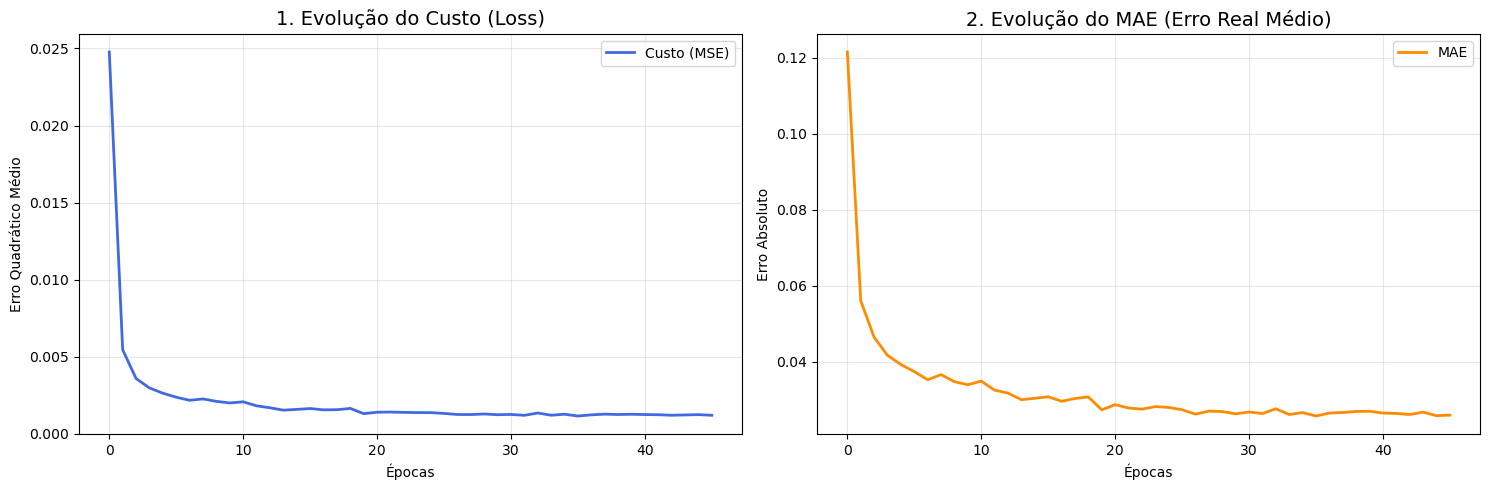

In [33]:
import matplotlib.pyplot as plt

# Define o tamanho da imagem (largura, altura)
plt.figure(figsize=(15, 5))

# --- GRÁFICO 1: Custo (Loss/MSE) ---
# O MSE é o que a rede usa para "aprender". Ele penaliza erros grandes.
plt.subplot(1, 2, 1) 
plt.plot(historico_loss, label='Custo (MSE)', color='royalblue', linewidth=2)
plt.title('1. Evolução do Custo (Loss)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Erro Quadrático Médio')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRÁFICO 2: Erro Médio Absoluto (MAE) ---
# O MAE é mais fácil de entender: ele diz, em média, quanto a previsão errou no valor real.
plt.subplot(1, 2, 2)
plt.plot(historico_mae, label='MAE', color='darkorange', linewidth=2)
plt.title('2. Evolução do MAE (Erro Real Médio)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Erro Absoluto')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout() # Ajusta o espaçamento para não amassar os títulos
plt.savefig('erro_m13p2.png', dpi=300, bbox_inches='tight')

plt.show()

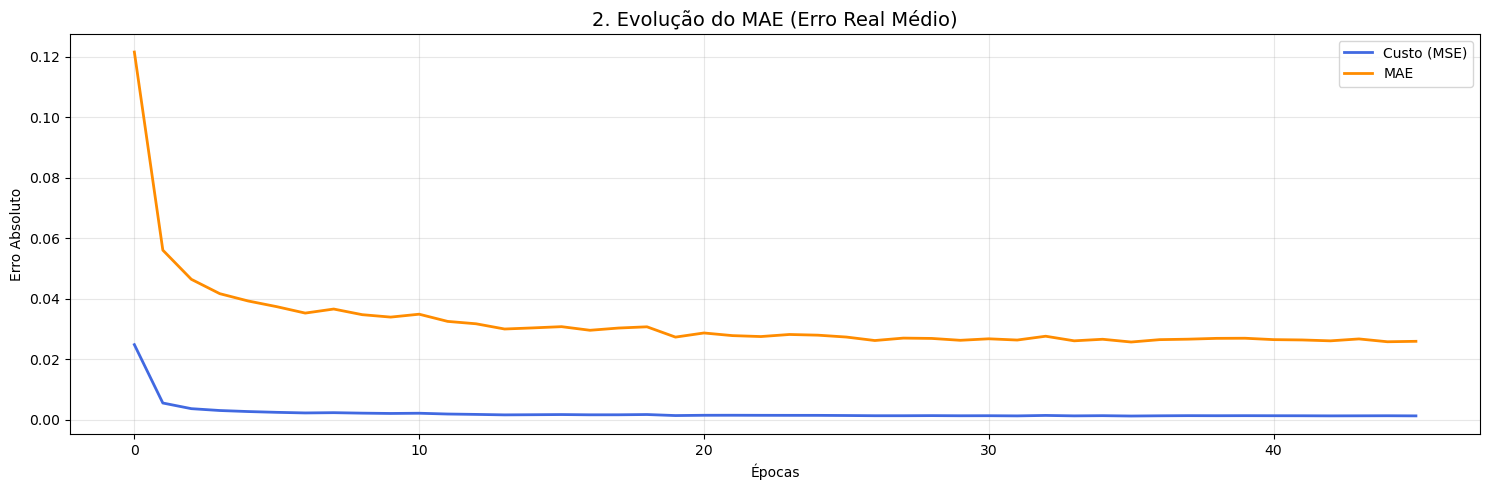

In [34]:
import matplotlib.pyplot as plt

# Define o tamanho da imagem (largura, altura)
plt.figure(figsize=(15, 5))

# --- GRÁFICO 1: Custo (Loss/MSE) ---
# O MSE é o que a rede usa para "aprender". Ele penaliza erros grandes.
#plt.subplot(1, 2, 1) 
plt.plot(historico_loss, label='Custo (MSE)', color='royalblue', linewidth=2)
plt.title('1. Evolução do Custo (Loss)', fontsize=14)
plt.xlabel('Épocas')
#plt.ylabel('Erro Quadrático Médio')
plt.legend()
plt.grid(True, alpha=0.3)

# --- GRÁFICO 2: Erro Médio Absoluto (MAE) ---
# O MAE é mais fácil de entender: ele diz, em média, quanto a previsão errou no valor real.
#plt.subplot(1, 2, 2)
plt.plot(historico_mae, label='MAE', color='darkorange', linewidth=2)
plt.title('2. Evolução do MAE (Erro Real Médio)', fontsize=14)
plt.xlabel('Épocas')
plt.ylabel('Erro Absoluto')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout() # Ajusta o espaçamento para não amassar os títulos
plt.show()

A. A Curva em "L" (O Ideal)
Se a linha começa lá no alto e desce rapidamente, ficando quase horizontal (um platô) depois de algumas épocas:

Significado: A rede aprendeu os padrões principais e agora está apenas refinando detalhes. Isso indica um treinamento bem-sucedido.

B. A Curva "Serra" (Instabilidade)
Se a linha fica subindo e descendo loucamente como os dentes de uma serra:

Significado:  Taxa de Aprendizado (lr) está alta demais. O otimizador está dando passos tão grandes que ele "atropela" o ponto de acerto e cai no erro novamente.

C. A Curva Reta (O Modelo "Burro")
Se a linha começa alta e continua reta ou desce quase nada:

Significado: A rede não está conseguindo extrair padrões. Geralmente acontece se os dados não foram normalizados corretamente ou se a arquitetura da LSTM é simples demais para o problema.

===================

#### Interpretando o último gráfico

Convergência Estável: Note que ambas as curvas despencam logo nas primeiras 5 épocas. Isso indica que os hiperparâmetros (como a taxa de aprendizado e o otimizador Adam) estão muito bem ajustados. O modelo não teve dificuldade em entender a tendência principal dos dados.

O "Platô" (Épocas 20 a 45): A partir da época 20, as linhas ficam quase horizontais. Isso significa que o modelo atingiu o seu limite de aprendizado com essa arquitetura. Ele parou de tentar "decorar" e se estabilizou em um erro médio constante.

Diferença de Escala (Laranja vs Azul):

O MSE (Azul) está muito próximo de zero. Isso acontece porque o MSE eleva o erro ao quadrado. Como seus dados estão entre 0 e 1, o quadrado de um número pequeno fica ainda menor.

O MAE (Laranja) está estabilizado em torno de 0.025 a 0.03.

Interpretação Real: Isso significa que, em média, a IA está errando apenas 2,5% a 3% do valor real. Para uma série temporal, esse é um resultado excelente.

## Etapa 5: Processamento da base de teste

In [37]:
base_teste = pd.read_csv('petr4_teste.csv')
base_teste.columns[1:2]


Index(['Open'], dtype='object')

In [38]:
preco_real_teste = base_teste.iloc[:, 1:2].values

In [39]:

base_completa = pd.concat([base, base_teste])

In [40]:
base.tail(2)

,Date,Open,High,Low,Close,Adj Close,Volume
1243,2017-12-28,16.1,16.129999,16.0,16.1,16.067865,19011500.0
1244,2017-12-29,16.1,16.100000,16.1,16.1,16.067865,0.0


In [41]:
base_teste.tail(2)

,Date,Open,High,Low,Close,Adj Close,Volume
20,2018-01-30,19.77,19.77,19.360001,19.490000,19.451097,46203000
21,2018-01-31,19.74,19.93,19.680000,19.700001,19.660681,41576600


In [42]:
base_completa.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2013-01-02,19.990000,20.209999,19.690001,19.690001,18.086271,30182600.0
1,2013-01-03,19.809999,20.400000,19.700001,20.400000,18.738441,30552600.0
2,2013-01-04,20.330000,20.620001,20.170000,20.430000,18.766001,36141000.0
3,2013-01-07,20.480000,20.670000,19.950001,20.080000,18.444506,28069600.0
4,2013-01-08,20.110001,20.230000,19.459999,19.500000,17.911745,29091300.0


In [43]:
base_completa = base_completa.drop('Date', axis = 1)

In [45]:
entradas = base_completa[len(base_completa) - len(base_teste) - 90:].values


In [47]:
entradas[0:5]

array([[1.3930000e+01, 1.4030000e+01, 1.3760000e+01, 1.3870000e+01,
        1.3842316e+01, 2.7208100e+07],
       [1.3760000e+01, 1.3850000e+01, 1.3680000e+01, 1.3850000e+01,
        1.3822356e+01, 2.7306400e+07],
       [1.3790000e+01, 1.3900000e+01, 1.3440000e+01, 1.3450000e+01,
        1.3423154e+01, 5.8871700e+07],
       [1.3530000e+01, 1.3770000e+01, 1.3470000e+01, 1.3650000e+01,
        1.3622754e+01, 8.2909400e+07],
       [1.3850000e+01, 1.4190000e+01, 1.3820000e+01, 1.4020000e+01,
        1.3992017e+01, 6.0260300e+07]])

In [48]:
len(entradas)

112

In [49]:
entradas = normalizador.transform(entradas)

In [50]:
# repetir o processo para o x apenas
X_teste = []
for i in range(90, 112):
    X_teste.append(entradas[i-90:i, 0:6])
X_teste = np.array(X_teste)

In [51]:
X_teste = torch.tensor(X_teste, device = device, dtype = torch.float32)

In [55]:
len(X_teste[:1])

1

In [56]:
X_teste[:1] #90 dias e 6 colunas de uma linha, depois nos demais a mesma coisa

tensor([[[0.4714, 0.4731, 0.4933, 0.4750, 0.4750, 0.0389],
         [0.4632, 0.4644, 0.4893, 0.4740, 0.4740, 0.0391],
         [0.4646, 0.4668, 0.4770, 0.4543, 0.4543, 0.0842],
         [0.4520, 0.4605, 0.4785, 0.4641, 0.4641, 0.1186],
         [0.4675, 0.4809, 0.4964, 0.4823, 0.4823, 0.0862],
         [0.4729, 0.4804, 0.5026, 0.4897, 0.4897, 0.0260],
         [0.5024, 0.5032, 0.5174, 0.5015, 0.5015, 0.0808],
         [0.5063, 0.5211, 0.5317, 0.5314, 0.5314, 0.0979],
         [0.5242, 0.5211, 0.5578, 0.5314, 0.5314, 0.0000],
         [0.5281, 0.5274, 0.5409, 0.5162, 0.5162, 0.0520],
         [0.5174, 0.5225, 0.5471, 0.5300, 0.5300, 0.0500],
         [0.5223, 0.5279, 0.5496, 0.5241, 0.5241, 0.0711],
         [0.5203, 0.5250, 0.5471, 0.5319, 0.5319, 0.0530],
         [0.5247, 0.5327, 0.5578, 0.5324, 0.5324, 0.0492],
         [0.5266, 0.5284, 0.5563, 0.5324, 0.5324, 0.0684],
         [0.5242, 0.5293, 0.5558, 0.5324, 0.5324, 0.0681],
         [0.5281, 0.5284, 0.5527, 0.5373, 0.5373, 0.0513

## Etapa 6: Previsões

In [57]:
# validação
# Este comando avisa a rede neural: "Pare de aprender e apenas preveja".
# Dropout é desativado.
regressor.eval()
#O modelo pega cada janela de 90 dias que ele nunca viu antes e passa pelas camadas LSTM que você treinou.
#O resultado (previsoes) é um Tensor do PyTorch contendo os palpites da rede (ainda na escala de 0 a 1).
previsoes = regressor(X_teste)

#Como a rede entrega um objeto complexo do PyTorch, precisamos "limpar" esse dado para usá-lo em gráficos ou tabelas:
#.detach(): Corta a ligação do valor com o "gráfico de gradientes". 
#Como não vamos mais treinar, não precisamos guardar o histórico de como esse número foi calculado.
#.cpu(): Tira o dado da memória da placa de vídeo (GPU) e traz de volta para a memória RAM (Processador).
#.numpy(): Converte o Tensor do PyTorch em uma matriz NumPy comum.
#.reshape(-1, 1): Garante que o resultado seja uma coluna vertical.
#Isso é obrigatório para que você possa usar o normalizador.inverse_transform() depois.

previsoes = previsoes.detach().cpu().numpy().reshape(-1, 1)

In [58]:
previsoes

array([[0.58139604],
       [0.5856127 ],
       [0.5927727 ],
       [0.60225636],
       [0.6110958 ],
       [0.61819476],
       [0.62377256],
       [0.6259526 ],
       [0.62722814],
       [0.6298029 ],
       [0.6341823 ],
       [0.64130116],
       [0.65464365],
       [0.6709798 ],
       [0.68467027],
       [0.6932162 ],
       [0.69539934],
       [0.700413  ],
       [0.7118168 ],
       [0.72912115],
       [0.74687487],
       [0.757408  ]], dtype=float32)

In [63]:
# 1. Cria um NOVO objeto normalizador específico para a saída (target)
# Por que fazer isso? Porque o 'normalizador' original aprendeu a escala 
# de 6 colunas, mas a sua rede neural cospe apenas 1 coluna de previsão.
normalizador_previsao = MinMaxScaler(feature_range = (0, 1))

# 2. O comando .fit() "treina" este novo normalizador apenas com a 1ª coluna
# base_treinamento[:, 0:1] pega todas as linhas da coluna de índice 0.
# O fit() descobre qual é o Valor Mínimo e o Valor Máximo REAIS dessa coluna específica.
# Isso cria uma "ponte" de tradução exclusiva para os preços.
normalizador_previsao.fit(base_treinamento[:, 0:1])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [64]:
normalizador_previsao.get_params()

{'clip': False, 'copy': True, 'feature_range': (0, 1)}

In [65]:
previsoes = normalizador_previsao.inverse_transform(previsoes)

In [66]:
previsoes

array([[16.200014],
       [16.287046],
       [16.434828],
       [16.630571],
       [16.813017],
       [16.95954 ],
       [17.074665],
       [17.119661],
       [17.145988],
       [17.199131],
       [17.289522],
       [17.436455],
       [17.711845],
       [18.049023],
       [18.331594],
       [18.507982],
       [18.553041],
       [18.656523],
       [18.891897],
       [19.24906 ],
       [19.615498],
       [19.832901]], dtype=float32)

In [67]:
previsoes.mean()

17.726809

In [68]:
preco_real_teste.mean()

17.87454563636364

# Previsão melhor, com a previsão de ações

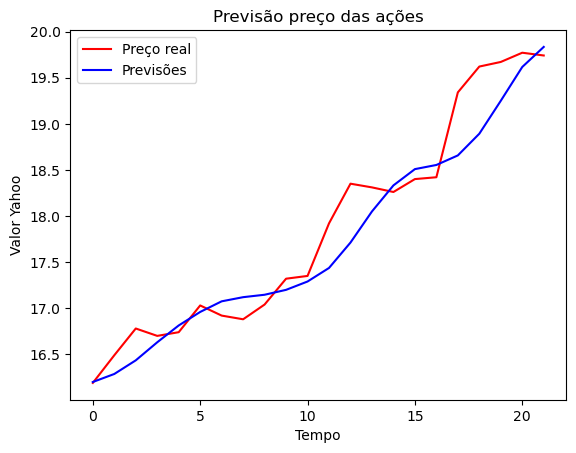

In [69]:
plt.plot(preco_real_teste, color = 'red', label = 'Preço real')
plt.plot(previsoes, color = 'blue', label = 'Previsões')
plt.title('Previsão preço das ações')
plt.xlabel('Tempo')
plt.ylabel('Valor Yahoo')
plt.legend()